In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [51]:
import gc
import pandas as pd
import pymc as pm
from pathlib import Path
from models import weighted_update, bayesian_update
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [52]:
# load and filter the data -------------------------------------------------------------
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
main_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)

# Test

In [53]:
hrd_df = main_df[((main_df.cohort == "vmp1") & (main_df.task == "hrd-session1"))]
hrd_df = hrd_df[hrd_df.participant_id.isin(hrd_df.participant_id.unique()[:10])]

In [54]:
# extract variables for the model ------------------------------------------------------
n = hrd_df.participant_id.nunique()

participant_codes_intero_del_1 = pd.Categorical(
    hrd_df[hrd_df.Modality == "Intero"].participant_id
).codes

participant_codes_extero_del_1 = pd.Categorical(
    hrd_df[hrd_df.Modality == "Extero"].participant_id
).codes

heart_rate_del_1 = hrd_df[hrd_df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2_del_1 = hrd_df[hrd_df.Modality == "Intero"].responseBPM.to_numpy()
intero_decision_del_1 = (
    hrd_df[hrd_df.Modality == "Intero"].Decision.to_numpy() == "More"
).astype(int)

extero_tone_1_del_1 = hrd_df[hrd_df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2_del_1 = hrd_df[hrd_df.Modality == "Extero"].responseBPM.to_numpy()
extero_decision_del_1 = (
    hrd_df[hrd_df.Modality == "Extero"].Decision.to_numpy() == "More"
).astype(int)

In [55]:
idata_del_1, _ = weighted_update(
    heart_rate=heart_rate_del_1,
    intero_tone_2=intero_tone_2_del_1,
    extero_tone_1=extero_tone_1_del_1,
    extero_tone_2=extero_tone_2_del_1,
    extero_decision=extero_decision_del_1,
    intero_decision=intero_decision_del_1,
    n=n,
    participant_codes_extero=participant_codes_extero_del_1,
    participant_codes_intero=participant_codes_intero_del_1,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,1,0.17,63
,2000,0,0.18,63
,2000,0,0.18,15
,2000,0,0.18,63


In [56]:
sensitivity_del_1 = az.summary(
    idata_del_1,
    var_names=["sensitivity"],
)["mean"].to_numpy()
precision_del_1 = az.summary(
    idata_del_1,
    var_names=["pi_cardiac_belief"],
)["mean"].to_numpy()
mean_del_1 = az.summary(
    idata_del_1,
    var_names=["mu_cardiac_prior"],
)["mean"].to_numpy()

# Re-test

In [57]:
hrd_df = main_df[~((main_df.cohort == "vmp1") & (main_df.task == "hrd-session1"))]
hrd_df = hrd_df[hrd_df.participant_id.isin(hrd_df.participant_id.unique()[:10])]

In [58]:
# extract variables for the model ------------------------------------------------------
n = hrd_df.participant_id.nunique()

participant_codes_intero_del_2 = pd.Categorical(
    hrd_df[hrd_df.Modality == "Intero"].participant_id
).codes

participant_codes_extero_del_2 = pd.Categorical(
    hrd_df[hrd_df.Modality == "Extero"].participant_id
).codes

heart_rate_del_2 = hrd_df[hrd_df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2_del_2 = hrd_df[hrd_df.Modality == "Intero"].responseBPM.to_numpy()
intero_decision_del_2 = (
    hrd_df[hrd_df.Modality == "Intero"].Decision.to_numpy() == "More"
).astype(int)

extero_tone_1_del_2 = hrd_df[hrd_df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2_del_2 = hrd_df[hrd_df.Modality == "Extero"].responseBPM.to_numpy()
extero_decision_del_2 = (
    hrd_df[hrd_df.Modality == "Extero"].Decision.to_numpy() == "More"
).astype(int)

In [59]:
idata_del_2, _ = weighted_update(
    heart_rate=heart_rate,
    intero_tone_2=intero_tone_2,
    extero_tone_1=extero_tone_1,
    extero_tone_2=extero_tone_2,
    extero_decision=extero_decision,
    intero_decision=intero_decision,
    n=n,
    participant_codes_extero=participant_codes_extero,
    participant_codes_intero=participant_codes_intero,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,2,0.18,63
,2000,1,0.18,63
,2000,0,0.17,63
,2000,0,0.17,31


In [60]:
sensitivity_del_2 = az.summary(
    idata_del_2,
    var_names=["sensitivity"],
)["mean"].to_numpy()
precision_del_2 = az.summary(
    idata_del_2,
    var_names=["pi_cardiac_belief"],
)["mean"].to_numpy()
mean_del_2 = az.summary(
    idata_del_2,
    var_names=["mu_cardiac_prior"],
)["mean"].to_numpy()

## Visualisation

## Reliability

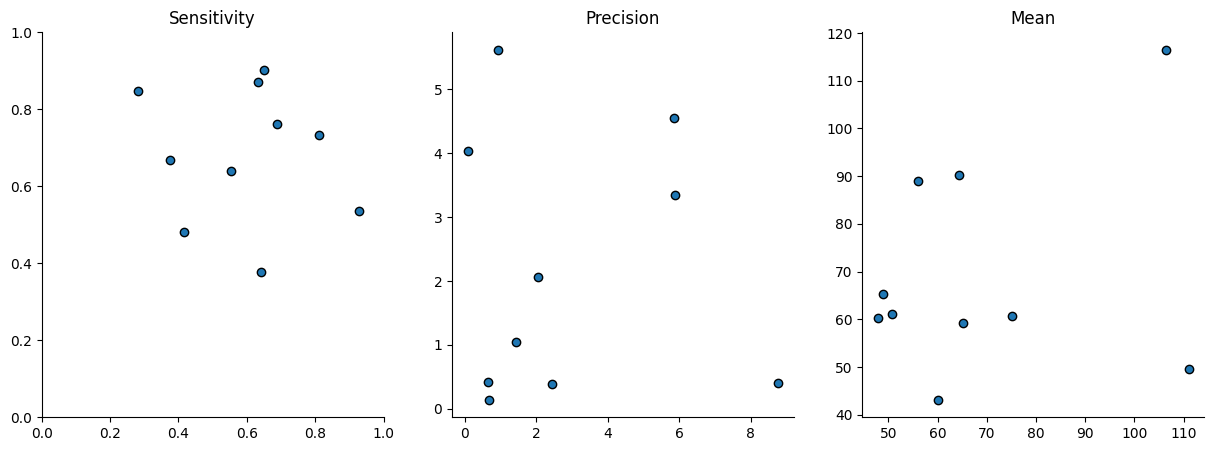

In [61]:
_, axs = plt.subplots(figsize=(15, 5), ncols=3)
axs[0].scatter(sensitivity_del_1, sensitivity_del_2, edgecolors="k")
axs[0].set(title="Sensitivity", xlim=(0, 1), ylim=(0, 1))
axs[1].scatter(precision_del_1, precision_del_2, edgecolors="k")
axs[1].set(title="Precision")
axs[2].scatter(mean_del_1, mean_del_2, edgecolors="k")
axs[2].set(title="Mean")
sns.despine()

## Heart rate

In [91]:
participant_id = 0

expected_heart_rate_del_1 = az.summary(
    idata_del_1,
    var_names=[
        "mus_cardiac_belief",
    ],
)["mean"].to_numpy()[participant_codes_intero_del_1 == participant_id]
heart_rate_del_1_ = heart_rate_del_1[participant_codes_intero_del_1 == participant_id]

expected_heart_rate_del_2 = az.summary(
    idata_del_2,
    var_names=[
        "mus_cardiac_belief",
    ],
)["mean"].to_numpy()[participant_codes_intero_del_2 == participant_id]
heart_rate_del_2_ = heart_rate_del_2[participant_codes_intero_del_2 == participant_id]

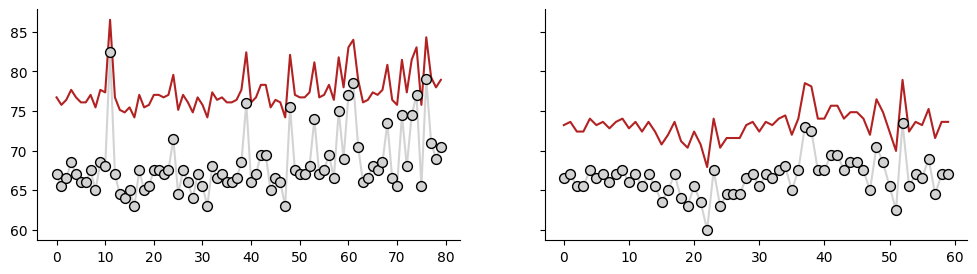

In [92]:
_, axs = plt.subplots(figsize=(12, 3), ncols=2, sharey=True)

axs[0].scatter(
    np.arange(0, len(heart_rate_del_1_)),
    heart_rate_del_1_,
    s=50,
    color="lightgrey",
    edgecolors="k",
)
axs[0].plot(
    np.arange(0, len(heart_rate_del_1_)),
    heart_rate_del_1_,
    color="lightgrey",
    zorder=-1,
)

axs[0].plot(
    np.arange(0, len(heart_rate_del_1_)),
    expected_heart_rate_del_1,
    color="firebricK",
    zorder=-1,
)


axs[1].scatter(
    np.arange(0, len(heart_rate_del_2_)),
    heart_rate_del_2_,
    s=50,
    color="lightgrey",
    edgecolors="k",
)
axs[1].plot(
    np.arange(0, len(heart_rate_del_2_)),
    heart_rate_del_2_,
    color="lightgrey",
    zorder=-1,
)

axs[1].plot(
    np.arange(0, len(heart_rate_del_2_)),
    expected_heart_rate_del_2,
    color="firebricK",
    zorder=-1,
)

sns.despine()

In [93]:
print(
    f"Sensitivity Del1: {sensitivity_del_1[participant_id]} - Del2: {sensitivity_del_2[participant_id]}"
)

Sensitivity Del1: 0.81 - Del2: 0.733
